<a href="https://colab.research.google.com/github/Edw12/omics_data_analysis/blob/main/Colab_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

# Remove the directory if it already exists to ensure a clean clone
if os.path.exists('omics_data_analysis'):
    !rm -rf omics_data_analysis

# Retrieve GitHub Token from Colab Secrets
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

# Clone the private repository using the PAT
!git clone https://{GITHUB_TOKEN}@github.com/Edw12/omics_data_analysis.git

Cloning into 'omics_data_analysis'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 61 (delta 22), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 495.67 KiB | 13.04 MiB/s, done.
Resolving deltas: 100% (22/22), done.


In [2]:
import sys

# Add the cloned repository to sys.path so Python can find its modules
sys.path.insert(0, '/content/omics_data_analysis')

In [3]:
import os
import sys
import importlib
import pandas as pd # Required for pd.ExcelFile in the modification logic

# --- Modify Random_Forest_Analysis.py for correct imports ---
rf_analysis_path = '/content/omics_data_analysis/Functions/Random_Forest_Analysis.py'
with open(rf_analysis_path, 'r') as f:
    rf_lines = f.readlines()

new_rf_lines = []
for line in rf_lines:
    if "from load_human_metabolites import load_human_metabolites" in line:
        new_rf_lines.append("from ..sup_func.load_human_metabolites import load_human_metabolites\n")
    elif "from Plot_Model_Results import Plot_Model_Results" in line:
        new_rf_lines.append("from ..sup_func.Plot_Model_Results import Plot_Model_Results\n")
    else:
        new_rf_lines.append(line)

with open(rf_analysis_path, 'w') as f:
    f.writelines(new_rf_lines)

print(f"Modified {rf_analysis_path} for correct imports.")

# --- Modify load_human_metabolites.py for correct file path and ensure imports ---
lm_path = '/content/omics_data_analysis/sup_func/load_human_metabolites.py'
with open(lm_path, 'r') as f:
    original_lm_lines = f.readlines()

desired_imports = ['import os\n', 'import pandas as pd\n']

# Filter out existing desired imports to avoid duplication, but keep other lines
filtered_lm_lines = []
for line in original_lm_lines:
    # Check if the line (stripped) is exactly one of the desired imports
    if line.strip() not in [imp.strip() for imp in desired_imports]:
        filtered_lm_lines.append(line)

new_lm_content = []
# Add desired imports at the very beginning of the file
new_lm_content.extend(desired_imports)

# Add the filtered original content, applying the path modification
for line in filtered_lm_lines:
    if 'file = pd.ExcelFile("human metabolites transposed.xlsx")' in line:
        # Construct the full path using os.path.join for robustness
        new_lm_content.append("    file_path = os.path.join(os.path.dirname(os.path.dirname(__file__)), 'Data', 'human metabolites transposed.xlsx')\n")
        new_lm_content.append("    file = pd.ExcelFile(file_path)\n")
    else:
        new_lm_content.append(line)

with open(lm_path, 'w') as f:
    f.writelines(new_lm_content)

print(f"Modified {lm_path} for correct data file path and ensured 'import os', 'import pandas'.")

# --- Reload modules after file modifications ---
# Before re-importing, remove the modules from sys.modules to force a fresh load
if 'omics_data_analysis.sup_func.load_human_metabolites' in sys.modules:
    del sys.modules['omics_data_analysis.sup_func.load_human_metabolites']
if 'omics_data_analysis.Functions.Random_Forest_Analysis' in sys.modules:
    del sys.modules['omics_data_analysis.Functions.Random_Forest_Analysis']

print("Modules removed from sys.modules cache for fresh reload.")

Modified /content/omics_data_analysis/Functions/Random_Forest_Analysis.py for correct imports.
Modified /content/omics_data_analysis/sup_func/load_human_metabolites.py for correct data file path and ensured 'import os', 'import pandas'.
Modules removed from sys.modules cache for fresh reload.


In [4]:
import sys

# Ensure the repository path is in sys.path
if '/content/omics_data_analysis' not in sys.path:
    sys.path.insert(0, '/content/omics_data_analysis')

# Import the specific functions from the freshly loaded modules
from omics_data_analysis.sup_func.Plot_Model_Results import Plot_Model_Results
from omics_data_analysis.sup_func.load_human_metabolites import load_human_metabolites
from omics_data_analysis.Functions.Random_Forest_Analysis import Random_Forest_Analysis

In [5]:
Random_Forest_Analysis(load_human_metabolites, data_frame = True)

In [6]:
analysis = Random_Forest_Analysis(load_human_metabolites, data_frame = True, random_state=42)

In [8]:
collected, best_vals = analysis.tune_hyperparams(out = True, n_seeds = 3)

[0]: Random state 8 took 195.300s to run.
[1]: Random state 77 took 186.303s to run.
[2]: Random state 65 took 187.910s to run.
For random state 8, the correctly allocated fraction was 32/40 

For random state 77, the correctly allocated fraction was 29/40 

For random state 65, the correctly allocated fraction was 28/40 

The average success was 70.000%
--- Results of Hyperparameter testing ---
Averages / summaries across runs:
  n_estimators : 166.7  (numeric mean, from [200, 200, 100])
  min_samples_split : 5.667  (numeric mean, from [10, 5, 2])
  min_samples_leaf : 4  (numeric mean, from [1, 1, 10])
  max_features : mode = log2 (2/3 runs)  full distribution = {'sqrt': 1, 'log2': 2}
  max_depth : 7.333  (numeric mean, from [7, 5, 10])
  ccp_alpha : 0.003667  (numeric mean, from [0.0, 0.01, 0.001])


In [9]:
analysis.generate_classifier(parameters = best_vals, out = True)

The number of splits was 5, the smallest class was Diabetic_Male
generate_classifier took 0.339s to run.


(np.int64(28), 40)

The runtime of classifier_scores is 3 minutes and 57.403 seconds
The balanced accuracy score was: 0.6733193277310924 
The permutation score was 0.6230769230769231 and the p value for the permutations was 0.004975124378109453 

Explained variability per principal component: [0.56256678 0.18471022]
The proportion of correct allocations is 28/40 
which is 70.0%


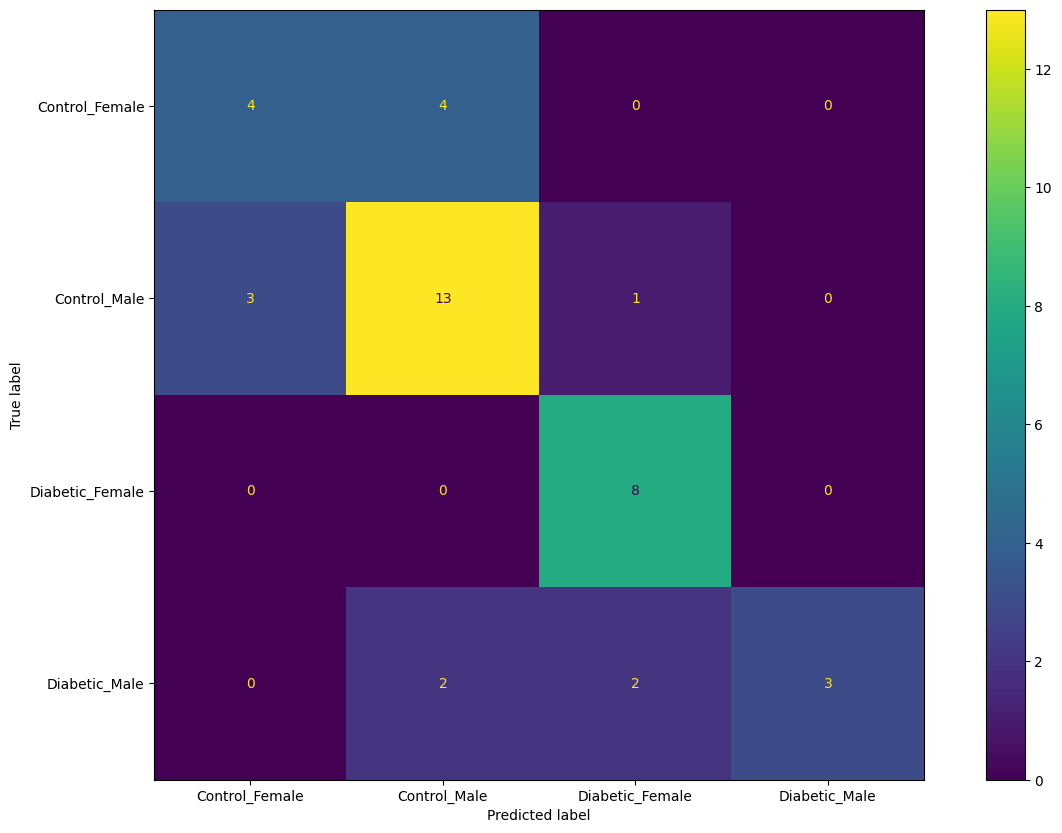

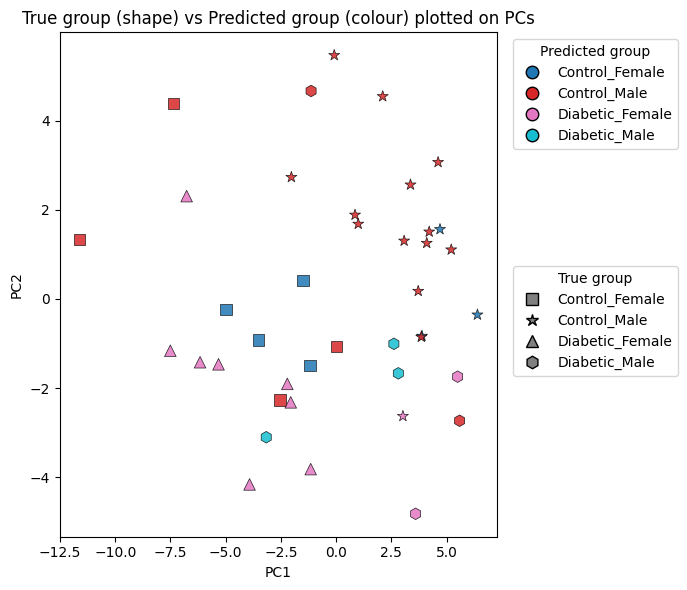

In [10]:
analysis.classifier_scores()
analysis.Plot_Results()

In [11]:
analysis.find_important(use_val = False)
analysis.MI_matrix()

The top 30 features: 
     importance_mean  importance_std  lower_bound  significant
87          0.005412        0.002853    -0.000294        False
105         0.005376        0.002028     0.001321         True
97          0.005095        0.001692     0.001711         True
106         0.005086        0.001987     0.001113         True
98          0.003697        0.001934    -0.000171        False
166         0.002910        0.001361     0.000188         True
83          0.002897        0.001654    -0.000411        False
30          0.002487        0.001551    -0.000615        False
85          0.002435        0.001185     0.000064         True
174         0.002379        0.001476    -0.000574        False
36          0.002342        0.001751    -0.001161        False
117         0.002318        0.000734     0.000851         True
170         0.002056        0.000971     0.000114         True
202         0.001824        0.000870     0.000084         True
22          0.001764        0.001

In [ ]:
analysis.partial_dependance_plots(target = "Diabetic_Female", n = 4, pri_pairs = True)
analysis.partial_dependance_plots(target = "Diabetic_Male", n = 4, pri_pairs = True)
analysis.partial_dependance_plots(target = "Control_Female", n = 4, pri_pairs = True)
analysis.partial_dependance_plots(target = "Control_Male", n = 4, pri_pairs = True)